In [7]:
import pandas as pd

# Đọc file CSV với đường dẫn chính xác từ notebook
df = pd.read_csv("../data/lazada_all_reviews2.csv")

# Xem 5 dòng đầu tiên
print(df.head())

# Xem danh sách các cột
print(df.columns)



   STT  Trang Thời gian đánh giá      Tên         Chứng nhận  \
0    1      1        25 Mar 2025  tran P.  Verified Purchase   
1    2      1        25 Mar 2025  tran P.  Verified Purchase   
2    3      1        25 Mar 2025  tran P.  Verified Purchase   
3    4      1        25 Feb 2025    7***4  Verified Purchase   
4    5      1        25 Feb 2025    7***4  Verified Purchase   

                                            Nội dung              Phân loại  \
0  Hoàn hảo cho trang phục thường ngày, Vải thoải...  Màu:XÁM TRẮNG, Size:M   
1  đã nhận đc hàng, vải áo đẹp phù hợp với giá ti...     Màu:MÀU BE, Size:M   
2  Thiết kế thời trang với những chi tiết sọc., V...   Màu:XÁM XANH, Size:M   
3  Sự thoải mái:  có dãn nhẹ. \n Phong cách:   Hợ...     Màu:MÀU BE, Size:L   
4  Sự thoải mái:  Vải thoải mái và thoáng khí., \...   Màu:XANH ĐEN, Size:L   

   Lượt thích  Số sao                                                URL  
0           2       5  https://www.lazada.vn/products/pdp-i232246

In [8]:
# Đếm số lượng đánh giá cho từng mức sao
star_counts = df["Số sao"].value_counts().sort_index()

print("Số lượng đánh giá theo số sao:")
print(star_counts)


Số lượng đánh giá theo số sao:
Số sao
1      108
2       41
3      145
4      213
5    10534
Name: count, dtype: int64


In [9]:
avg_rating = df["Số sao"].mean()
print(f"Điểm trung bình đánh giá: {avg_rating:.2f} sao")


Điểm trung bình đánh giá: 4.90 sao


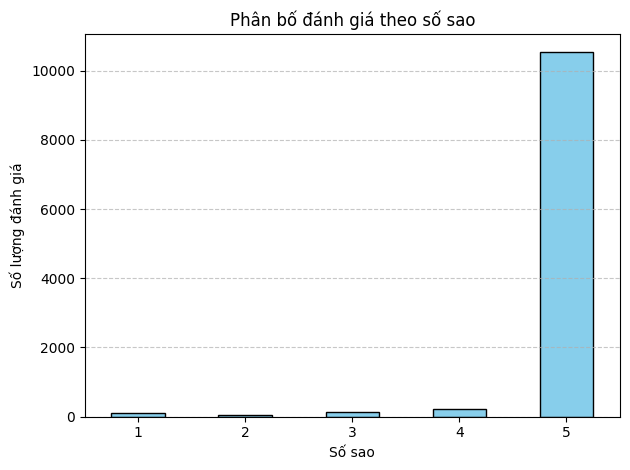

In [12]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ
star_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Phân bố đánh giá theo số sao")
plt.xlabel("Số sao")
plt.ylabel("Số lượng đánh giá")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


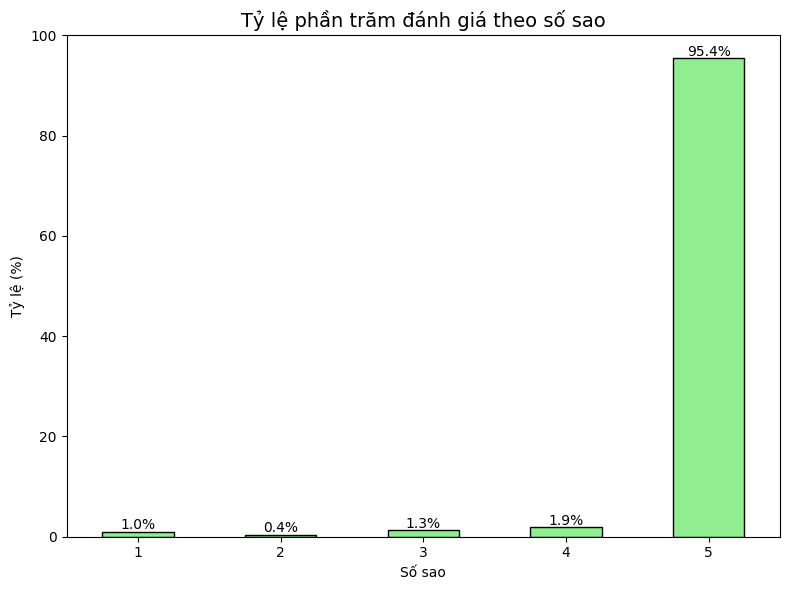

In [2]:
import matplotlib.pyplot as plt

# Tính phần trăm đánh giá theo số sao
rating_counts = df['Số sao'].value_counts().sort_index()
rating_percent = (rating_counts / rating_counts.sum()) * 100

# Vẽ biểu đồ cột thể hiện phần trăm
plt.figure(figsize=(8, 6))
ax = rating_percent.plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title("Tỷ lệ phần trăm đánh giá theo số sao", fontsize=14)
plt.xlabel("Số sao")
plt.ylabel("Tỷ lệ (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)

# Ghi phần trăm lên đầu mỗi cột
for i, v in enumerate(rating_percent.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\QUANG TRUNG\AppData\Local\Temp\ipykernel_10648\2246799373.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_avg, y="Tên rút gọn", x="mean", palette="magma")
C:\Users\QUANG TRUNG\AppData\Local\Temp\ipykernel_10648\2246799373.py:29: UserWarning: Glyph 20008 (\N{CJK UNIFIED IDEOGRAPH-4E28}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\QUANG TRUNG\AppData\Local\Temp\ipykernel_10648\2246799373.py:29: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\QUANG TRUNG\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20008 (\N{CJK UNIFIED IDEOGRAPH-4E28}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\QUANG TRUNG\AppData\Roaming\Python\Python313\site-pack

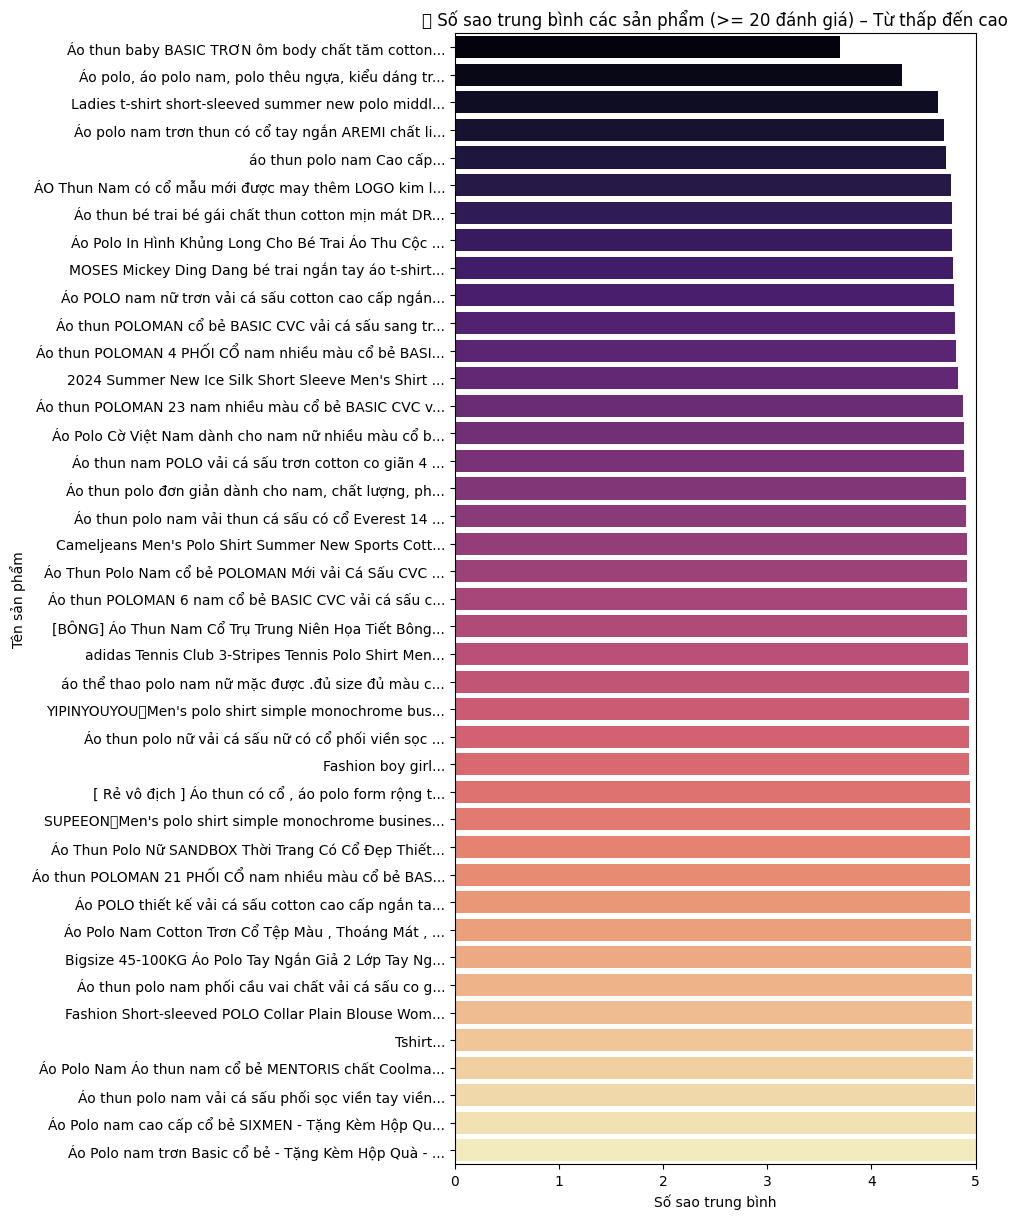

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df_reviews = pd.read_csv("../data/lazada_all_reviews2.csv")
df_products = pd.read_csv("../data/lazada_all_products2.csv")

# Tiền xử lý
df_reviews["Số sao"] = pd.to_numeric(df_reviews["Số sao"], errors="coerce")
df = pd.merge(df_reviews, df_products[["URL", "Tên sản phẩm"]], on="URL", how="left")

# Tính trung bình số sao
df_avg = df.groupby("Tên sản phẩm")["Số sao"].agg(["mean", "count"]).reset_index()
df_avg = df_avg[df_avg["count"] >= 20]
df_avg = df_avg.sort_values("mean", ascending=True)

# Tạo cột rút gọn tên sản phẩm
df_avg["Tên rút gọn"] = df_avg["Tên sản phẩm"].str.slice(0, 50) + "..."

# Vẽ biểu đồ
plt.figure(figsize=(10, len(df_avg) * 0.3))
sns.barplot(data=df_avg, y="Tên rút gọn", x="mean", palette="magma")

plt.title("Số sao trung bình các sản phẩm (>= 20 đánh giá) – Từ thấp đến cao")
plt.xlabel("Số sao trung bình")
plt.ylabel("Tên sản phẩm")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()